<a href="https://colab.research.google.com/github/dg6r/coursera/blob/master/VaporViaPipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing a library that is not in Colaboratory

To import a library that's not in Colaboratory by default, you can use `!pip install` or `!apt-get install`.

In [6]:
!pip install pyXSteam

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from pyXSteam.XSteam import XSteam
import math

# Инициализация таблицы свойств пара
steam = XSteam(XSteam.UNIT_SYSTEM_MKS)

# Параметры задачи
T_initial = 80      # начальная температура пара, °C
T_ambient = -40     # температура окружающей среды, °C
L = 6               # длина трубы, м
D = 0.08           # диаметр трубы, м (80 мм)
t_wall = 0.002     # толщина стенки, м (2 мм)
k_steel = 16       # теплопроводность нержавеющей стали, Вт/(м·К)
k_ice = 2.2       # теплопроводность льда, Вт/(м·К)
L_freeze = 334000  # удельная теплота замерзания, Дж/кг
P_system = 1       # давление в системе, бар

# Расходы пара, кг/ч
mass_flows = [12, 26, 51, 90, 153]

In [43]:
def calculate_with_freezing(m_dot_kg_h, T_in, T_amb, L, D, t_wall, k_steel, k_ice, L_freeze, P):
    # Переводим расход в кг/с
    m_dot = m_dot_kg_h / 3600

    # Внутренний диаметр
    D_inner = D - 2 * t_wall
    A_cross = math.pi * D_inner**2 / 4

    # Разбиваем трубу на 50 сегментов для точности
    n_segments = 50
    dx = L / n_segments
    x = np.linspace(0, L, n_segments + 1)

    # Массивы для хранения результатов
    T = np.zeros(n_segments + 1)  # температура пара
    T_wall = np.zeros(n_segments + 1)  # температура стенки
    m_steam = np.zeros(n_segments + 1)  # массовый расход пара
    m_cond = np.zeros(n_segments + 1)  # накопленная масса конденсата
    m_ice = np.zeros(n_segments + 1)   # накопленная масса льда
    ice_thickness = np.zeros(n_segments + 1)  # толщина ледяной корки

    # Начальные условия
    T[0] = T_in
    m_steam[0] = m_dot
    m_cond[0] = 0
    m_ice[0] = 0
    ice_thickness[0] = 0

    for i in range(n_segments):
        # Текущие параметры
        T_current = T[i]
        m_current = m_steam[i]
        ice_thick_current = ice_thickness[i]

        # Свойства пара на входе в сегмент
        rho_steam = steam.rho_pt(P, T_current)
        Cp_steam = steam.Cp_pt(P, T_current)
        mu_steam = steam.my_pt(P, T_current)
        k_steam = steam.tc_pt(P, T_current)

        # Скорость потока
        v = m_current / (rho_steam * A_cross)

        # Число Рейнольдса
        Re = rho_steam * v * D_inner / mu_steam

        # Число Нуссельта
        if Re < 2300:
            Nu = 4.36
        else:
            Pr = 1.0  # упрощённо
            Nu = 0.023 * Re**0.8 * Pr**0.4

        # Коэффициенты теплообмена
        h_inner = Nu * k_steam / D_inner
        h_outer = 25  # Вт/(м²·К) — естественная конвекция

        # Эффективный диаметр с учётом льда
        D_ice = D_inner + 2 * ice_thick_current

        # Общее термическое сопротивление (с учётом льда)
        R_total = (1 / (h_inner * math.pi * D_ice) +
                  math.log(D_ice / D_inner) / (2 * math.pi * k_ice) if ice_thick_current > 0 else 0 +
                  math.log(D / D_ice) / (2 * math.pi * k_steel) +
                  1 / (h_outer * math.pi * D))
        U = 1 / R_total if R_total > 0 else 1e6

        # Площадь теплообмена сегмента
        A_segment = math.pi * D * dx

        # Тепловой поток через стенку
        Q = U * A_segment * (T_current - T_amb)

        # Температура стенки (упрощённо)
        T_wall[i] = T_current - Q / (h_inner * A_segment)

        # Проверяем замерзание
        if T_wall[i] <= 0 and m_cond[i] > 0:
            # Часть конденсата замерзает
            Q_available = m_cond[i] * Cp_steam * (T_wall[i] - 0)  # тепло для охлаждения конденсата до 0 °C
            if Q_available >= L_freeze:
                m_frozen = min(m_cond[i], Q / L_freeze)
                m_ice[i+1] = m_ice[i] + m_frozen
                m_cond[i+1] = m_cond[i] - m_frozen
                # Рост толщины льда
                ice_thickness[i+1] = ice_thick_current + (m_frozen / (917 * math.pi * D_inner * dx))
            else:
                m_cond[i+1] = m_cond[i]
                m_ice[i+1] = m_ice[i]
        else:
            m_cond[i+1] = m_cond[i]
            m_ice[i+1] = m_ice[i]
            ice_thickness[i+1] = ice_thick_current

        # Охлаждение пара
        delta_T = Q / (m_current * Cp_steam)
        T[i+1] = T_current - delta_T
        m_steam[i+1] = m_current

    return x, T, m_steam * 3600, m_cond * 3600, m_ice * 3600, ice_thickness

In [47]:
# Расчёт для всех расходов
results_freeze = {}

KeyError: 12

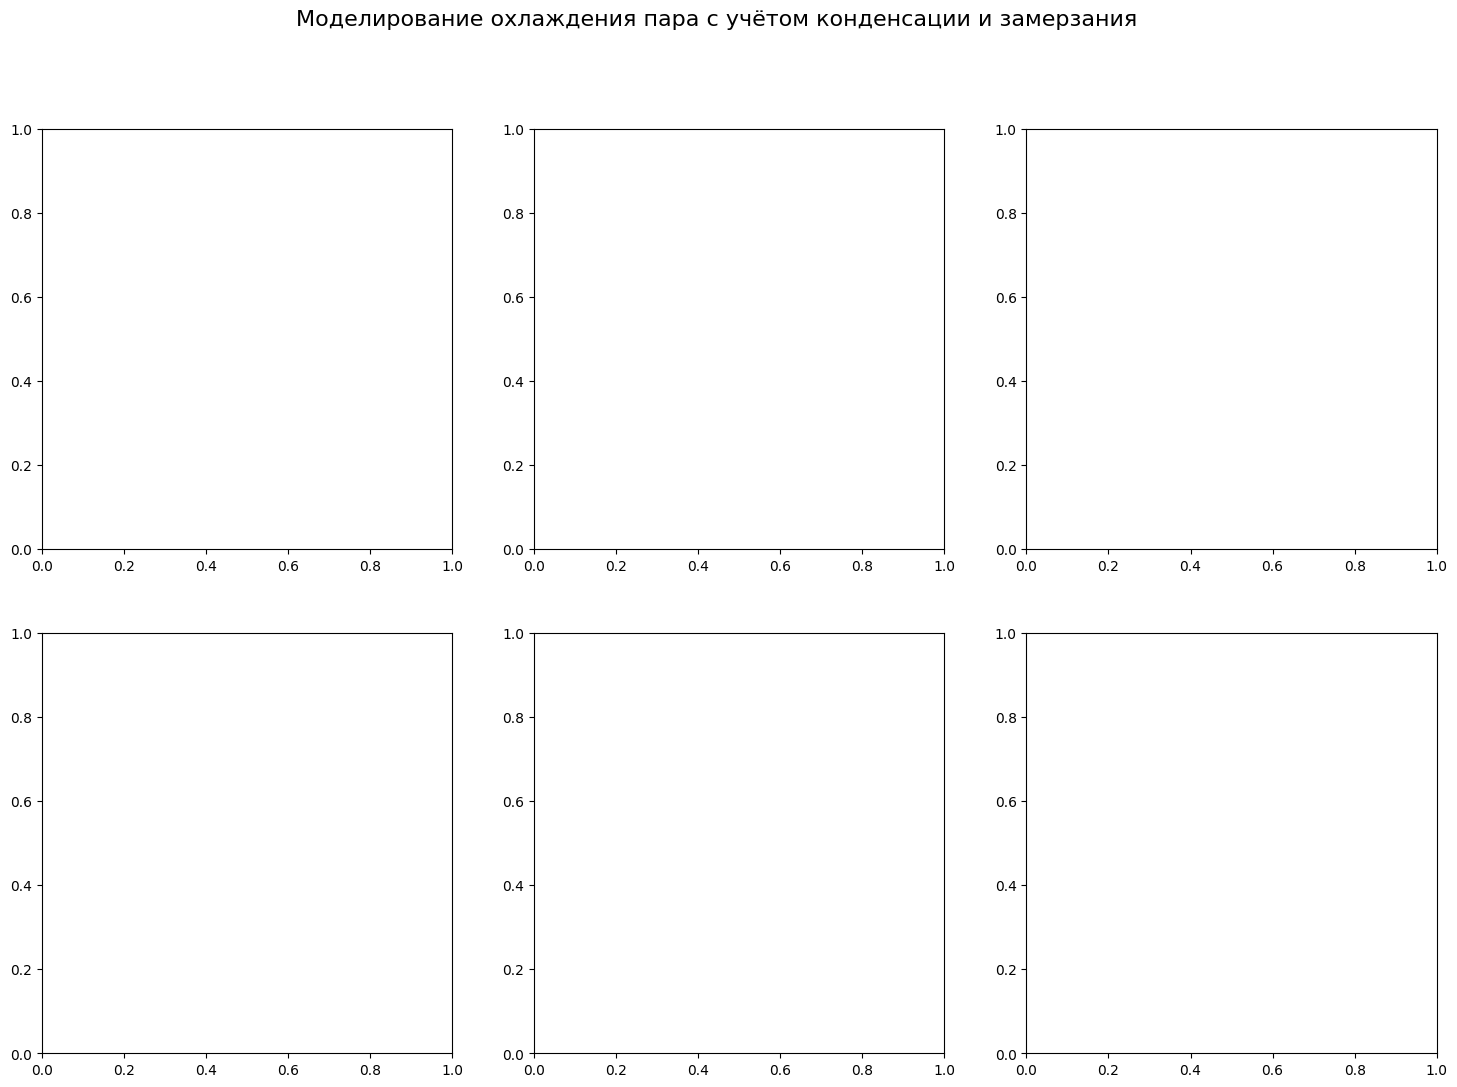

In [50]:
# Создаём фигуру с подграфиками (2 строки, 3 столбца)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Моделирование охлаждения пара с учётом конденсации и замерзания', fontsize=16)

# Общий список цветов для единообразия
colors = ['red', 'blue', 'green', 'purple', 'orange']

for idx, m_flow in enumerate(mass_flows):
    data = results_freeze[m_flow]
    x, T, m_steam, m_cond, m_ice, ice_thick = (
        data['x'], data['T'], data['m_steam'],
        data['m_cond'], data['m_ice'], data['ice_thick']
    )
    ax = axes[idx // 3, idx % 3]

    # Температура пара
    ax.plot(x, T, color=colors[idx], linewidth=2.5, label='Температура пара (°C)', marker='o', markersize=4)
    # Расход пара
    ax2 = ax.twinx()
    ax2.plot(x, m_steam, color='blue', linestyle='--', linewidth=1.5, label='Расход пара (кг/ч)')
    # Масса льда
    ax3 = ax.twinx()
    # Сдвигаем ось вправо для лучшей видимости
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, m_ice, color='cyan', linestyle='-.', linewidth=1.5, label='Масса льда (кг/ч)')

    # Настройка осей и подписей
    ax.set_xlabel('Длина трубы, м')
    ax.set_ylabel('Температура, °C', color=colors[idx])
    ax2.set_ylabel('Расход пара, кг/ч', color='blue')
    ax3.set_ylabel('Масса льда, кг/ч', color='cyan')

    ax.set_title(f'Расход {m_flow} кг/ч')
    ax.grid(True, alpha=0.3)

    # Легенда
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='best')

# Последний подграфик — сводные данные
ax = axes[1, 2]
outlet_temps = [results_freeze[m]['T'][-1] for m in mass_flows]
ice_at_end = [results_freeze[m]['m_ice'][-1] for m in mass_flows]

ax.plot(mass_flows, outlet_temps, 'ro-', linewidth=2.5, markersize=8, label='Температура на выходе (°C)')
ax2_last = ax.twinx()
ax2_last.plot(mass_flows, ice_at_end, 'bs--', linewidth=2, markersize=6, label='Масса льда на выходе (кг/ч)')
ax.set_xlabel('Расход пара, кг/ч')
ax.set_ylabel('Температура на выходе, °C', color='red')
ax2_last.set_ylabel('Масса льда на выходе, кг/ч', color='blue')
ax.set_title('Сводные результаты')
ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_last.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()

# Дополнительный график: толщина ледяной корки для всех расходов
plt.figure(figsize=(12, 8))
for idx, m_flow in enumerate(mass_flows):
    x = results_freeze[m_flow]['x']
    ice_thick = results_freeze[m_flow]['ice_thick']
    plt.plot(x, np.array(ice_thick) * 1000,  # переводим в мм
              color=colors[idx], linewidth=2,
              label=f'Расход {m_flow} кг/ч (макс. толщина: {max(ice_thick)*1000:.2f} мм)')
plt.xlabel('Длина трубы, м')
plt.ylabel('Толщина ледяной корки, мм')
plt.title('Распределение толщины ледяной корки по длине трубы')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
